In [228]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [229]:
conn = sqlite3.connect("base_tratada.db")

query = """
SELECT *
FROM base_tratada;
"""

df = pd.read_sql(query, conn)

# Visualizar os dados
df.head()

#testando se o banco conectou

,preco,hospedes,quartos,camas,tipo_de_quarto,nota_avaliacao,noites_minimas,quantidade_avaliacoes,tipo_de_propriedade,latitude,...,banheiros,tipo_quarto_casa_apto_inteiro,tipo_quarto_quarto_compartilhado,tipo_quarto_quarto_hotel,tipo_quarto_quarto_privativo,tipo_de_propriedade_grupo,bairro_encode,ano_mes,ipca_mensal,ipca_acumulado_ano
0,580.0,4,2.0,3.0,casa_apto_inteiro,4.93,2,86,entire condo,-22.982818,...,1.5,1,0,0,0,1,76,2025-09-01 00:00:00,0.0048,0.0426
1,1900.0,2,1.0,1.0,casa_apto_inteiro,NaN,5,0,entire rental unit,-22.984090,...,2.0,1,0,0,0,1,34,2025-09-01 00:00:00,0.0048,0.0426
2,700.0,4,1.0,1.0,casa_apto_inteiro,NaN,1,0,entire rental unit,-22.814911,...,1.0,1,0,0,0,1,96,2025-09-01 00:00:00,0.0048,0.0426
3,NaN,2,NaN,NaN,quarto_privativo,5.00,2,3,private room in rental unit,-22.981910,...,1.0,0,0,0,1,4,76,2025-09-01 00:00:00,0.0048,0.0426
4,500.0,4,1.0,1.0,casa_apto_inteiro,4.91,2,11,entire rental unit,-23.010000,...,1.0,1,0,0,0,1,8,2025-09-01 00:00:00,0.0048,0.0426


In [230]:
df_tratado = df[df["preco"] <= 7000].copy()

#Limita o preco das diaria ate 7k

In [231]:
df_tratado_price_min = df_tratado[
    (df_tratado["preco"] >= 65) &
    (df_tratado["quartos"] <= 15) &
    (df_tratado["banheiros"] <= 12)
].copy()

#atribui ao novo dataframe valores de limete pós remocao de outliers

In [232]:
df_tratado_price_min[
    [
        "preco",
        "hospedes",
        "quartos",
        "camas",
        "nota_avaliacao",
        "noites_minimas",
        "quantidade_avaliacoes",
        "latitude",
        "longitude",
        "banheiros",
        "tipo_de_quarto"
    ]
].describe()
df_tratado_price_min.info()

<class 'pandas.DataFrame'>
Index: 37711 entries, 0 to 43067
Data columns (total 24 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   preco                             37711 non-null  float64
 1   hospedes                          37711 non-null  int64  
 2   quartos                           37711 non-null  float64
 3   camas                             37700 non-null  float64
 4   tipo_de_quarto                    37711 non-null  str    
 5   nota_avaliacao                    30097 non-null  float64
 6   noites_minimas                    37711 non-null  int64  
 7   quantidade_avaliacoes             37711 non-null  int64  
 8   tipo_de_propriedade               37711 non-null  str    
 9   latitude                          37711 non-null  float64
 10  longitude                         37711 non-null  float64
 11  bairro                            37711 non-null  str    
 12  ano                 

In [233]:
variaveis = [
    "preco",
    "quartos",
    "banheiros",
    "latitude",
    "longitude",
    "camas",
    "nota_avaliacao",
    "quantidade_avaliacoes",
    "hospedes",
    "noites_minimas",
    "tipo_quarto_casa_apto_inteiro",
    "tipo_quarto_quarto_compartilhado",
    "tipo_quarto_quarto_hotel",
    "tipo_quarto_quarto_privativo",
    "tipo_de_propriedade_grupo",
    "ipca_mensal",
    "ipca_acumulado_ano"
]

df_corr = df_tratado_price_min[variaveis]

In [234]:
corr_matrix = df_corr.corr()

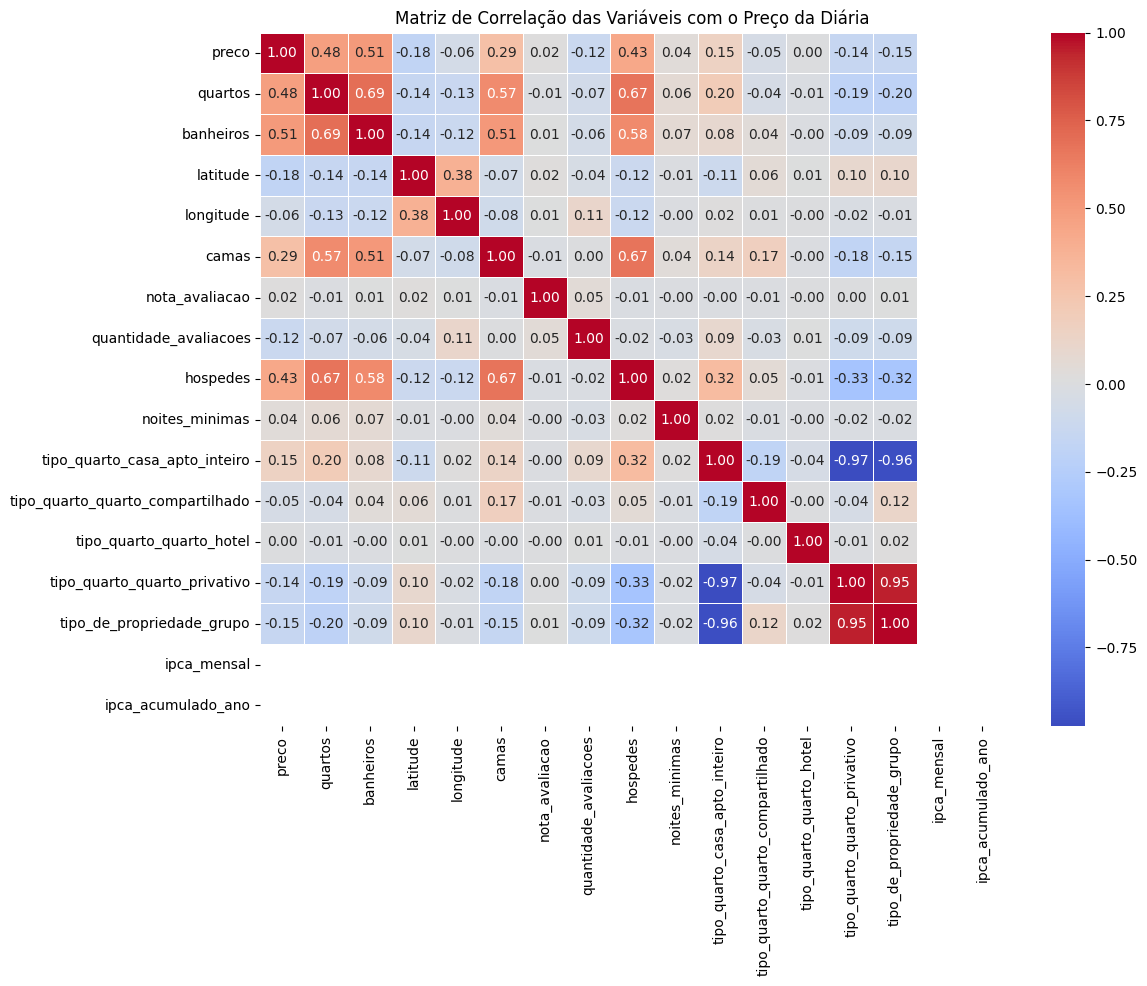

In [235]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de Correlação das Variáveis com o Preço da Diária")
plt.show()

MODELO EXTRA TREES

In [236]:
# variável alvo
y = df_tratado_price_min["preco"]

# variáveis explicativas
X = df_tratado_price_min.drop(columns=["preco", "ano_mes", "bairro_encode", "bairro", "tipo_de_propriedade", "tipo_de_quarto", "ano", "mes", "ipca_acumulado_ano", "ipca_mensal"])
X.head()


,hospedes,quartos,camas,nota_avaliacao,noites_minimas,quantidade_avaliacoes,latitude,longitude,banheiros,tipo_quarto_casa_apto_inteiro,tipo_quarto_quarto_compartilhado,tipo_quarto_quarto_hotel,tipo_quarto_quarto_privativo,tipo_de_propriedade_grupo
0,4,2.0,3.0,4.93,2,86,-22.982818,-43.222457,1.5,1,0,0,0,1
1,2,1.0,1.0,NaN,5,0,-22.984090,-43.191770,2.0,1,0,0,0,1
2,4,1.0,1.0,NaN,1,0,-22.814911,-43.379011,1.0,1,0,0,0,1
4,4,1.0,1.0,4.91,2,11,-23.010000,-43.344820,1.0,1,0,0,0,1
5,6,2.0,6.0,4.93,2,89,-22.970696,-43.186048,2.0,1,0,0,0,1


In [237]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
#train/test split, separa em dados para treino e para teste

In [238]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor

modelo = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train, y_train)
#treina o modelo pela primeira vez

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the 

In [239]:
y_pred = modelo.predict(X_test)

In [240]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_full = mean_absolute_error(y_test, y_pred)
rmse_full = np.sqrt(mean_squared_error(y_test, y_pred))
r2_full = r2_score(y_test, y_pred)

In [241]:
print("MODELO COMPLETO SEM LOG")
print("MAE:", mae_full)
print("RMSE:", rmse_full)
print("R²:", r2_full)

MODELO COMPLETO SEM LOG
MAE: 260.74766955394495
RMSE: 524.3939071936775
R²: 0.4210715754741491


In [242]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias)
#o modelo escolhe quais variaveis sao mais importantes

banheiros                           0.178693
longitude                           0.141800
latitude                            0.139076
quartos                             0.115501
hospedes                            0.112204
noites_minimas                      0.084203
nota_avaliacao                      0.076280
camas                               0.057460
quantidade_avaliacoes               0.054083
tipo_quarto_casa_apto_inteiro       0.025791
tipo_de_propriedade_grupo           0.011139
tipo_quarto_quarto_privativo        0.003026
tipo_quarto_quarto_compartilhado    0.000674
tipo_quarto_quarto_hotel            0.000072
dtype: float64


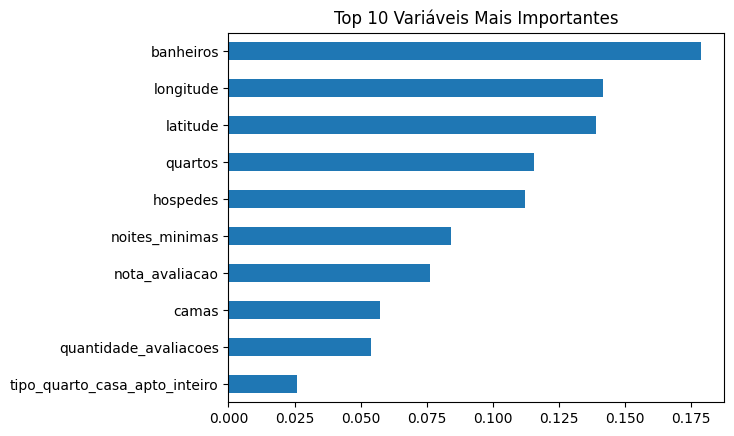

In [243]:
importancias.head(10).plot(kind="barh")
plt.title("Top 10 Variáveis Mais Importantes")
plt.gca().invert_yaxis()
plt.show()
#grafico com as variaveis mais importantes

In [244]:
top_features = importancias.head(10).index.tolist()

print("Variáveis selecionadas:", top_features)
#pega as top variaveis mais importantes

Variáveis selecionadas: ['banheiros', 'longitude', 'latitude', 'quartos', 'hospedes', 'noites_minimas', 'nota_avaliacao', 'camas', 'quantidade_avaliacoes', 'tipo_quarto_casa_apto_inteiro']


In [245]:
X = X[top_features]
#redefine o X com essas variaveis

In [246]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
#separa entre train/test novamente

In [247]:
modelo.fit(X_train, y_train)
#treina o modelo novamente

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the 

In [248]:
y_pred = modelo.predict(X_test)
#previsao

In [249]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MODELO REDUZIDO SEM LOG")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
#avalia o desempenho do modelo

MODELO REDUZIDO SEM LOG
MAE: 259.649649549231
RMSE: 521.164073647585
R²: 0.4281810558775393


In [250]:
#MODELO COM TRANSFORMAÇÃO LOG
y = np.log(df_tratado_price_min["preco"])
X = df_tratado_price_min.drop(columns=["preco", "ano_mes", "bairro_encode", "bairro", "tipo_de_propriedade", "tipo_de_quarto", "ano", "mes", "ipca_acumulado_ano", "ipca_mensal"])



In [251]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
#train/test split, separa em dados para treino e para teste

In [252]:
modelo = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train, y_train)
#treina o modelo pela primeira vez

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the 

In [253]:
y_pred_log = modelo.predict(X_test)
y_pred = np.exp(y_pred_log)
y_test_real = np.exp(y_test)

In [254]:
mae_full = mean_absolute_error(y_test_real, y_pred)
rmse_full = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2_full = r2_score(y_test_real, y_pred)

In [255]:
print("MODELO COMPLETO COM LOG")
print("MAE:", mae_full)
print("RMSE:", rmse_full)
print("R²:", r2_full)

MODELO COMPLETO COM LOG
MAE: 229.13271079579482
RMSE: 511.16112356852494
R²: 0.4499207900010209


In [256]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias)
#o modelo escolhe quais variaveis sao mais importantes

latitude                            0.168575
banheiros                           0.147977
longitude                           0.127225
quartos                             0.125718
hospedes                            0.113990
nota_avaliacao                      0.078313
noites_minimas                      0.068117
quantidade_avaliacoes               0.061578
tipo_quarto_casa_apto_inteiro       0.048042
camas                               0.044976
tipo_de_propriedade_grupo           0.009547
tipo_quarto_quarto_compartilhado    0.003462
tipo_quarto_quarto_privativo        0.002229
tipo_quarto_quarto_hotel            0.000250
dtype: float64


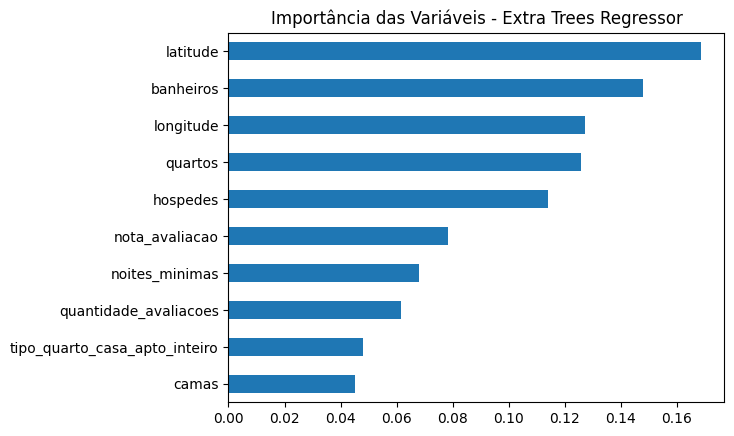

In [257]:
importancias.head(10).plot(kind="barh")
plt.title("Importância das Variáveis - Extra Trees Regressor")
plt.gca().invert_yaxis()
plt.show()
#grafico com as variaveis mais importantes

In [258]:
top_features = importancias.head(10).index.tolist()
X = X[top_features]

In [259]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
#separa entre train/test novamente

In [260]:
modelo.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the 

In [261]:
y_pred_log = modelo.predict(X_test)
y_pred = np.exp(y_pred_log)
y_test_real = np.exp(y_test)


In [262]:
mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2 = r2_score(y_test_real, y_pred)

In [263]:
print("MODELO REDUZIDO COM LOG")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MODELO REDUZIDO COM LOG
MAE: 228.9662400432077
RMSE: 510.6142682638492
R²: 0.4510971424675825


latitude                         0.172758
banheiros                        0.131513
quartos                          0.131419
longitude                        0.129879
hospedes                         0.125441
nota_avaliacao                   0.077637
noites_minimas                   0.069222
quantidade_avaliacoes            0.063894
tipo_quarto_casa_apto_inteiro    0.051089
camas                            0.047148
dtype: float64


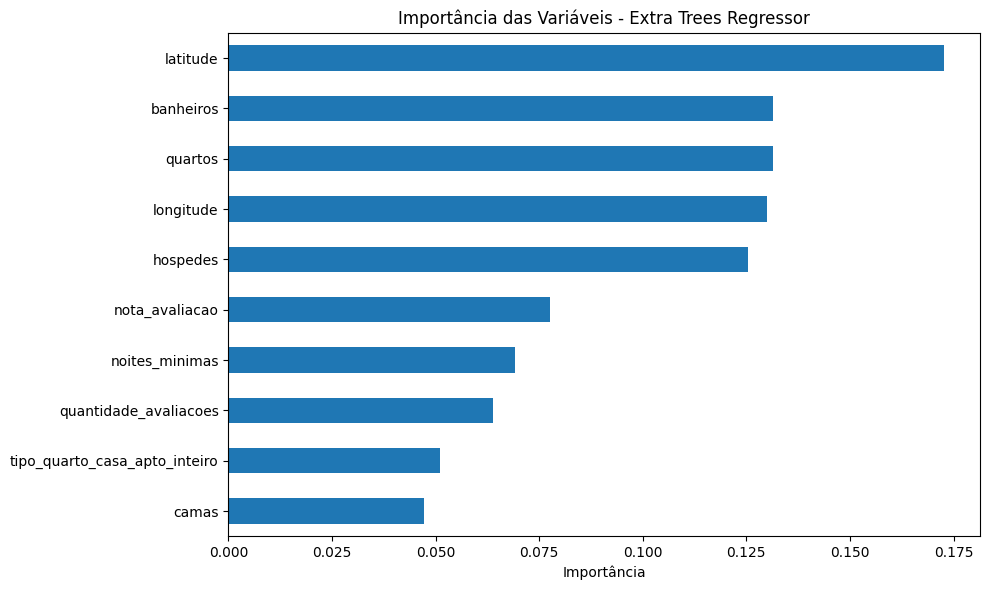

In [264]:
importancias_reduzido = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias_reduzido)

plt.figure(figsize=(10,6))
importancias_reduzido.plot(kind='barh')
plt.title("Importância das Variáveis - Extra Trees Regressor")
plt.gca().invert_yaxis()
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

In [265]:
# %pip install openpyxl

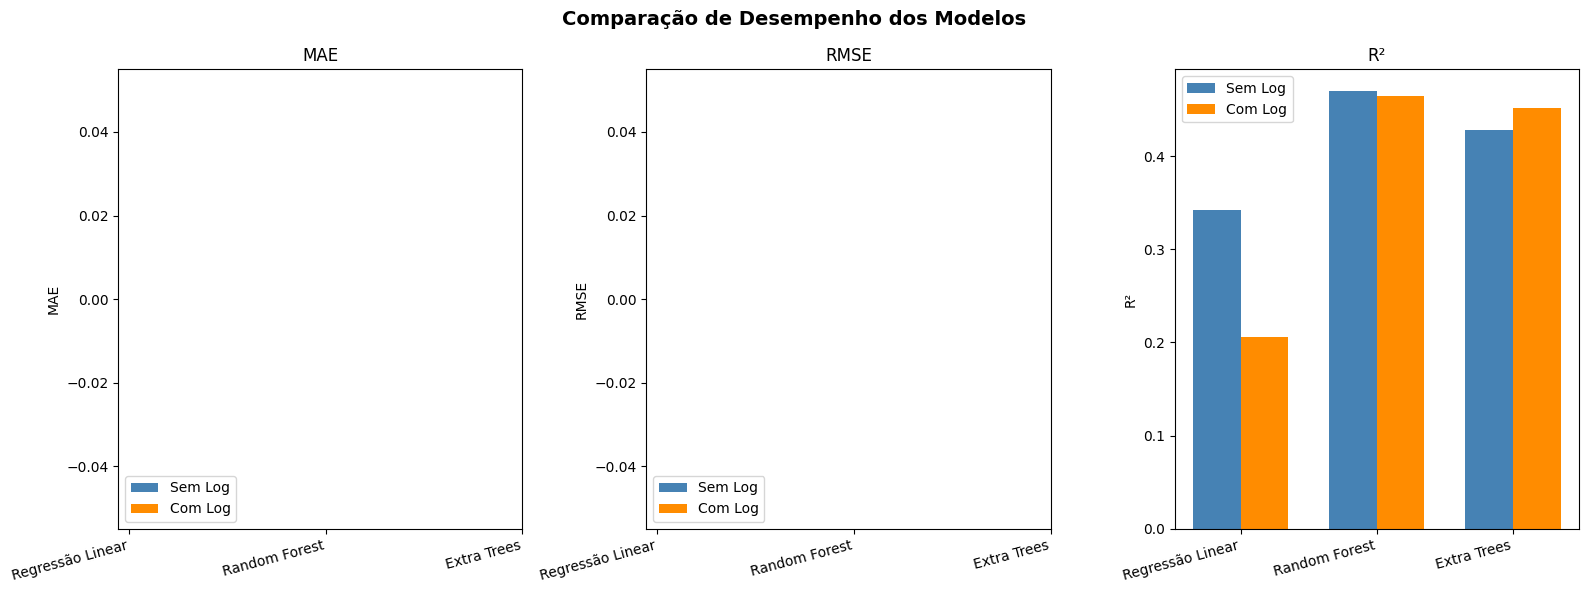

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df_metricas = pd.read_excel("./bases/MetricasModelos6.xlsx", index_col=0)

modelos = ["Reg_Linear", "Rand_Forest", "Ex_Trees"]
nomes_modelos = ["Regressão Linear", "Random Forest", "Extra Trees"]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metricas = {
    "MAE":  ("MAE_SLOG",  "MAE_CLOG"),
    "RMSE": ("RMSE_SLOG", "RMSE_CLOG"),
    "R²":   ("R2_SLOG",   "R2_CLOG")
}

x = np.arange(len(modelos))
largura = 0.35

for ax, (metrica, (sem_log, com_log)) in zip(axes, metricas.items()):
    valores_sem_log = df_metricas.loc[sem_log, modelos].values.astype(float)
    valores_com_log = df_metricas.loc[com_log, modelos].values.astype(float)

    # substitui valores absurdos por NaN para não distorcer o gráfico
    limite = 1e6
    valores_sem_log = np.where(valores_sem_log > limite, np.nan, valores_sem_log)
    valores_com_log = np.where(valores_com_log > limite, np.nan, valores_com_log)

    ax.bar(x - largura/2, valores_sem_log, width=largura, label="Sem Log", color="steelblue")
    ax.bar(x + largura/2, valores_com_log, width=largura, label="Com Log", color="darkorange")

    ax.set_xticks(x)
    ax.set_xticklabels(nomes_modelos, rotation=15, ha="right")
    ax.set_title(metrica)
    ax.set_ylabel(metrica)
    ax.legend()

plt.suptitle("Comparação de Desempenho dos Modelos", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("comparacao_modelos.png", dpi=300, bbox_inches="tight")
plt.show()
